::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`01_distributions.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/01_distributions.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`bestfitpy`, whose compiled core is a validated C++ port of the same library, so the
numbers below reproduce the upstream outputs exactly. The R version of this example
uses the same core and prints the same numbers.

## What you'll learn

- Creating and parameterizing distributions by family name.
- Computing PDF, CDF, and quantile values.
- Statistical properties (mean, variance, skewness, kurtosis).
- When to use each distribution.
- Random sampling, including Latin hypercube sampling.

The upstream notebook tours ten of the 42 univariate families in the library:
Normal, Log-Normal, GEV, Gamma, Weibull, Uniform, Triangular, PERT, Poisson, and
Binomial. This port keeps every family and condenses the long mathematical
derivations; see the upstream notebook for the full detail.

## Setup

The upstream setup loads the CoreCLR runtime and imports each distribution class
from `Numerics.Distributions`. Here one import covers everything, and every family
is constructed by name through `bf.Distribution`.

In [1]:
import bestfitpy as bf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Earth-tone palette used throughout
OLIVE, CLAY, SLATE, GRAY = "#6b7f3f", "#b06a3b", "#5b7a8c", "#8c8c7a"

print("Setup complete")

Setup complete


## Basic example: the Normal distribution

The Normal (Gaussian) distribution is the most widely used continuous
distribution. It arises naturally from the Central Limit Theorem: the sum of many
independent random variables tends toward a Normal distribution regardless of the
underlying distributions. It is parameterized by its mean $\mu$ and standard
deviation $\sigma$:

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right), \quad -\infty < x < \infty
$$

Note that the library reports Pearson (non-excess) kurtosis, which is 3.0 for a
Normal distribution. The "excess kurtosis" convention used by scipy/numpy is
Pearson minus 3.

**When to use:** symmetric data, many natural phenomena, Central Limit Theorem
applications.

Mean: 100.0
Standard Deviation: 15.0
Variance: 225.0
Skewness: 0.0
Kurtosis: 3.0
Minimum: -inf
Maximum: inf
5th Percentile: 75.32719559572791
Median: 100.0
95th Percentile: 124.67280440427207


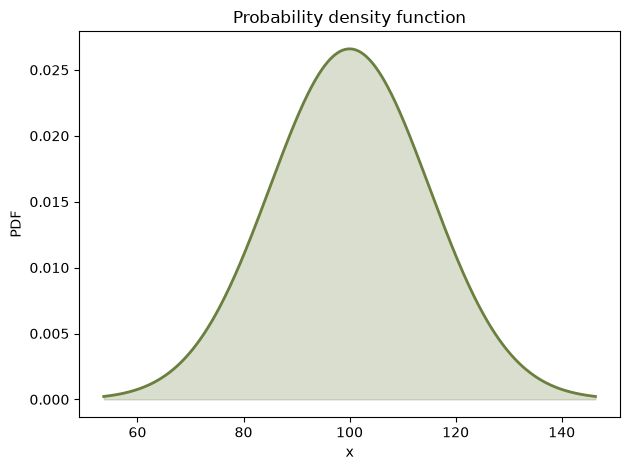

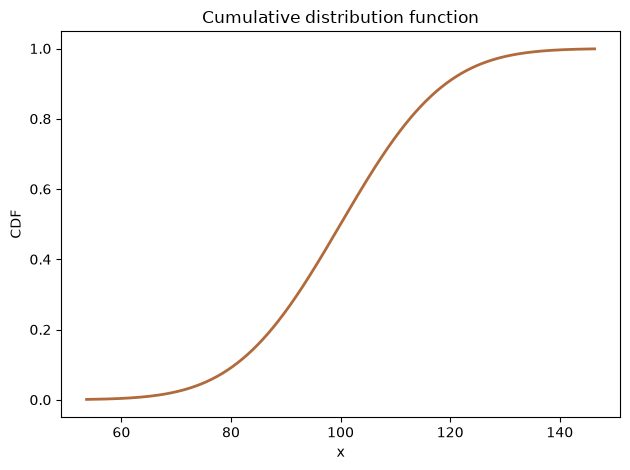

In [2]:
# Create Normal distribution -- Normal(mean=100, sd=15)
normal = bf.Distribution("Normal", [100, 15])
m = normal.moments()

print(f"Mean: {m['mean']}")
print(f"Standard Deviation: {m['sd']}")
print(f"Variance: {m['sd']**2}")
print(f"Skewness: {m['skewness']}")
print(f"Kurtosis: {m['kurtosis']}")
print(f"Minimum: {m['minimum']}")
print(f"Maximum: {m['maximum']}")
print(f"5th Percentile: {normal.quantile(0.05)}")
print(f"Median: {normal.quantile(0.5)}")
print(f"95th Percentile: {normal.quantile(0.95)}")

# Plot the PDF and CDF over the 0.1% to 99.9% quantile range.
# PDF/CDF/quantile all accept arrays directly.
x = np.linspace(normal.quantile(0.001), normal.quantile(0.999), 500)

plt.figure()
plt.plot(x, normal.pdf(x), color=OLIVE, linewidth=2)
plt.fill_between(x, normal.pdf(x), alpha=0.25, color=OLIVE)
plt.xlabel("x")
plt.ylabel("PDF")
plt.title("Probability density function")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, normal.cdf(x), color=CLAY, linewidth=2)
plt.xlabel("x")
plt.ylabel("CDF")
plt.title("Cumulative distribution function")
plt.tight_layout()
plt.show()

## Helper functions

Two small helpers make the rest of the tour concise: one plots the PDF and CDF
side by side, the other prints the statistics table the upstream notebook shows
for each family.

In [3]:
def plot_distribution(dist, x_range=None, n_points=500, title=None):
    """Plot PDF and CDF of a distribution."""
    if x_range is None:
        x_range = (dist.quantile(0.001), dist.quantile(0.999))
    x = np.linspace(x_range[0], x_range[1], n_points)

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(x, dist.pdf(x), color=OLIVE, linewidth=2)
    ax1.fill_between(x, dist.pdf(x), alpha=0.25, color=OLIVE)
    ax1.set_xlabel("x")
    ax1.set_ylabel("PDF")
    ax2.plot(x, dist.cdf(x), color=CLAY, linewidth=2)
    ax2.set_xlabel("x")
    ax2.set_ylabel("CDF")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def print_statistics(dist, name="Distribution"):
    """Print the statistics table upstream shows for each family."""
    m = dist.moments()
    df = pd.DataFrame({
        "Statistic": ["Mean", "Std Deviation", "Variance", "Skewness",
                      "Kurtosis", "Minimum", "Maximum", "5th Percentile",
                      "Median", "95th Percentile"],
        "Value": [m["mean"], m["sd"], m["sd"] ** 2, m["skewness"],
                  m["kurtosis"], m["minimum"], m["maximum"],
                  dist.quantile(0.05), dist.quantile(0.5),
                  dist.quantile(0.95)],
    })
    print(f"\n{name} statistics:")
    print(df.round(4).to_string(index=False))

## Continuous distributions

A parameterization note before the tour: the library uses its own parameter
conventions (for example, GEV uses $\xi$, $\alpha$, $\kappa$ in the Hosking
convention). If you compare to textbooks or SciPy, double-check the parameter
definitions. `d.parameter_names` shows the constructor order for any family.

### Log-Normal

A random variable $X$ follows a Log-Normal distribution if $\log(X)$ follows a
Normal distribution. It suits strictly positive, right-skewed data arising from
multiplicative processes. Matching the C# library, the `"LogNormal"` family uses
**base-10** logarithms: the parameters are the mean and standard deviation of
$\log_{10}(X)$. The upstream C# class has a mutable `Base` property; that is not
exposed here. Use the `"LnNormal"` family when you want the base-$e$ form.

**When to use:** right-skewed data that is always positive (flows, particle
sizes, incomes).


LogNormal(4.0, 0.5) statistics:
      Statistic        Value
           Mean 1.940096e+04
  Std Deviation 3.225447e+04
       Variance 1.040351e+09
       Skewness 9.582700e+00
       Kurtosis 3.468718e+02
        Minimum 0.000000e+00
        Maximum          inf
 5th Percentile 1.505127e+03
         Median 1.000000e+04
95th Percentile 6.643957e+04


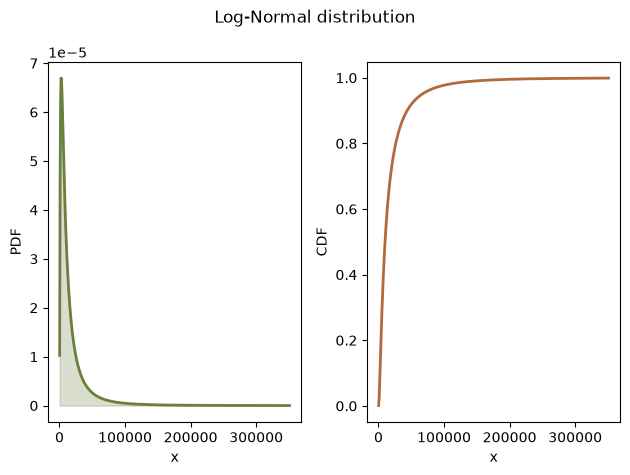

In [4]:
lognormal = bf.Distribution("LogNormal", [4.0, 0.5])

print_statistics(lognormal, "LogNormal(4.0, 0.5)")
plot_distribution(lognormal, title="Log-Normal distribution")

### Generalized Extreme Value (GEV)

The GEV distribution unifies three classical extreme value distributions into a
single three-parameter family. It is the limiting distribution for block maxima
(annual maximum floods, peak wind speeds) under the Fisher-Tippett-Gnedenko
theorem. The parameterization is location $\xi$, scale $\alpha > 0$, and shape
$\kappa$ in the Hosking convention, where the sign of $\kappa$ follows L-moment
theory:

$$
F(x) = \exp(-e^{-y}), \qquad
y = \begin{cases}
-\dfrac{1}{\kappa}\ln\!\left(1 - \kappa\dfrac{x - \xi}{\alpha}\right) & \kappa \neq 0 \\[6pt]
\dfrac{x - \xi}{\alpha} & \kappa = 0
\end{cases}
$$

- $\kappa < 0$: Frechet type (heavy upper tail, bounded below)
- $\kappa = 0$: Gumbel (unbounded)
- $\kappa > 0$: Weibull type (bounded above)

The mean exists when $|\kappa| < 1$ and the variance when $|\kappa| < 1/2$, which
is why two of the three tables below show NaN moments.

**When to use:** extreme events (floods, droughts, maxima and minima).

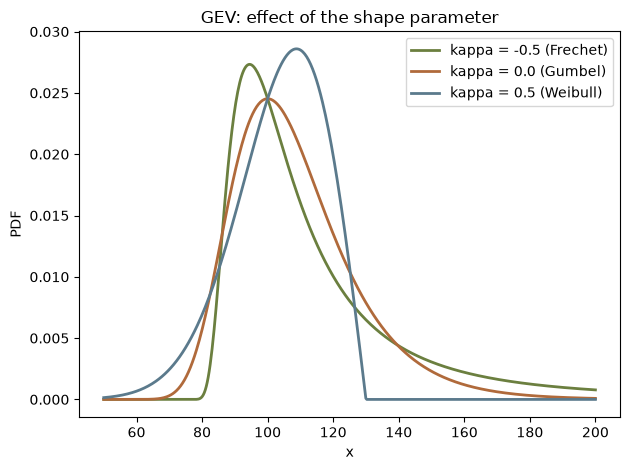


GEV (Frechet type) statistics:
      Statistic    Value
           Mean 123.1736
  Std Deviation      NaN
       Variance      NaN
       Skewness      NaN
       Kurtosis      NaN
        Minimum  70.0000
        Maximum      inf
 5th Percentile  87.3328
         Median 106.0337
95th Percentile 202.4619

GEV (Gumbel type) statistics:
      Statistic    Value
           Mean 108.6582
  Std Deviation  19.2382
       Variance 370.1102
       Skewness   1.1396
       Kurtosis   5.4000
        Minimum     -inf
        Maximum      inf
 5th Percentile  83.5422
         Median 105.4977
95th Percentile 144.5529

GEV (Weibull type) statistics:
      Statistic    Value
           Mean 103.4132
  Std Deviation      NaN
       Variance      NaN
       Skewness      NaN
       Kurtosis      NaN
        Minimum     -inf
        Maximum 130.0000
 5th Percentile  78.0754
         Median 105.0234
95th Percentile 123.2056


In [5]:
# Hosking convention: kappa < 0 => Frechet; kappa > 0 => Weibull type
gev_frechet = bf.Distribution("GeneralizedExtremeValue", [100, 15, -0.5])
gev_gumbel = bf.Distribution("GeneralizedExtremeValue", [100, 15, 0.0])
gev_weibull = bf.Distribution("GeneralizedExtremeValue", [100, 15, 0.5])

x = np.linspace(50, 200, 500)
plt.figure()
plt.plot(x, gev_frechet.pdf(x), color=OLIVE, linewidth=2, label="kappa = -0.5 (Frechet)")
plt.plot(x, gev_gumbel.pdf(x), color=CLAY, linewidth=2, label="kappa = 0.0 (Gumbel)")
plt.plot(x, gev_weibull.pdf(x), color=SLATE, linewidth=2, label="kappa = 0.5 (Weibull)")
plt.xlabel("x")
plt.ylabel("PDF")
plt.title("GEV: effect of the shape parameter")
plt.legend()
plt.tight_layout()
plt.show()

print_statistics(gev_frechet, "GEV (Frechet type)")
print_statistics(gev_gumbel, "GEV (Gumbel type)")
print_statistics(gev_weibull, "GEV (Weibull type)")

### Gamma

The Gamma distribution is a flexible two-parameter family for positive-valued
data. It generalizes the Exponential distribution and appears in waiting-time
problems, rainfall modeling, and Bayesian statistics. The factory name is
`"GammaDistribution"` (matching the C# class name), with scale $\theta$ first and
shape $\kappa$ second:

$$
f(x) = \frac{x^{\kappa-1}\, e^{-x/\theta}}{\theta^{\kappa}\,\Gamma(\kappa)}, \quad x > 0
$$

**When to use:** positive data, waiting times, rainfall amounts.


Gamma(scale=2, shape=0.5) statistics:
      Statistic   Value
           Mean  1.0000
  Std Deviation  1.4142
       Variance  2.0000
       Skewness  2.8284
       Kurtosis 15.0000
        Minimum  0.0000
        Maximum     inf
 5th Percentile  0.0039
         Median  0.4549
95th Percentile  3.8415


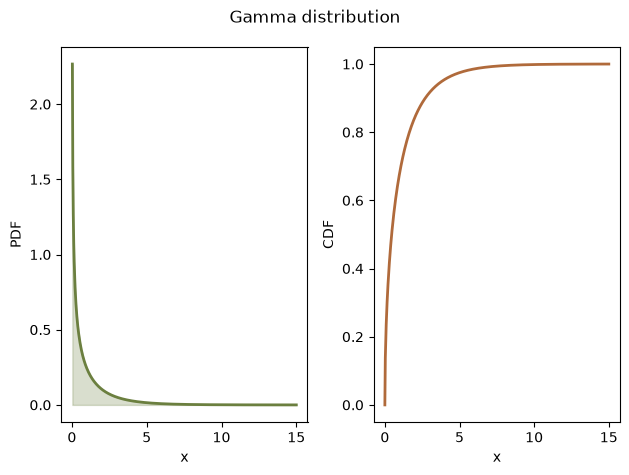

In [6]:
gamma = bf.Distribution("GammaDistribution", [2.0, 0.5])
print_statistics(gamma, "Gamma(scale=2, shape=0.5)")
plot_distribution(gamma, x_range=(0, 15), title="Gamma distribution")

### Weibull

The Weibull distribution is a flexible two-parameter model for nonnegative data.
Its shape parameter controls the failure rate: $\kappa < 1$ gives decreasing
hazard (early failures), $\kappa = 1$ reduces to the Exponential distribution, and
$\kappa > 1$ yields increasing hazard (wear-out):

$$
F(x) = 1 - \exp\left[-\left(\frac{x}{\lambda}\right)^{\kappa}\right], \quad x \ge 0
$$

**When to use:** reliability analysis, wind speeds, failure times.


Weibull(scale=100, shape=2.5) statistics:
      Statistic     Value
           Mean   88.7264
  Std Deviation   37.9667
       Variance 1441.4669
       Skewness    0.3586
       Kurtosis    2.8568
        Minimum    0.0000
        Maximum       inf
 5th Percentile   30.4807
         Median   86.3635
95th Percentile  155.0962


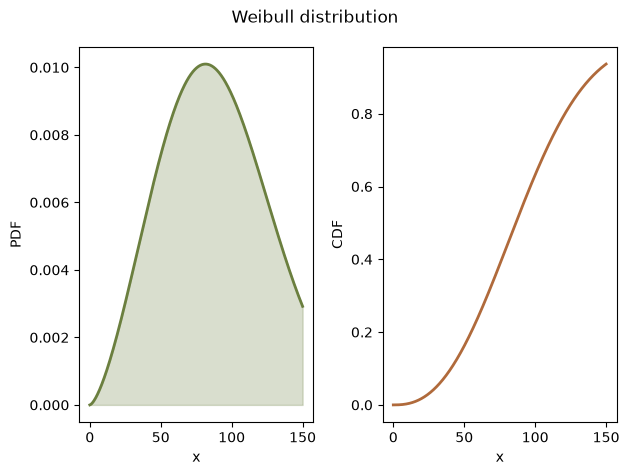

In [7]:
weibull = bf.Distribution("Weibull", [100, 2.5])
print_statistics(weibull, "Weibull(scale=100, shape=2.5)")
plot_distribution(weibull, x_range=(0, 150), title="Weibull distribution")

## Bounded distributions

Three families for quantities with known bounds. The **Uniform** distribution
assigns equal density to every value in $[a, b]$: maximum uncertainty given only
the support. The **Triangular** distribution adds a most likely value (the mode)
between the bounds, a common shape for expert elicitation. The **PERT**
distribution (factory name `"Pert"`) takes the same minimum, most likely, and
maximum inputs but maps them to a smooth Beta density on $[a, b]$ with mean
$(a + 4c + b)/6$, giving gentler tails than the Triangular.

**When to use:** bounded quantities; Uniform when only the range is known,
Triangular or PERT when a most likely value is available (project estimates,
expert opinion).


Uniform(0, 100) statistics:
      Statistic    Value
           Mean  50.0000
  Std Deviation  28.8675
       Variance 833.3333
       Skewness   0.0000
       Kurtosis   1.8000
        Minimum   0.0000
        Maximum 100.0000
 5th Percentile   5.0000
         Median  50.0000
95th Percentile  95.0000


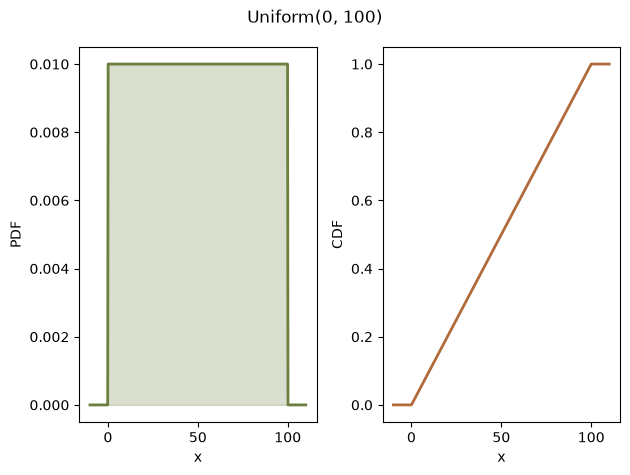

In [8]:
uniform = bf.Distribution("Uniform", [0, 100])
print_statistics(uniform, "Uniform(0, 100)")
plot_distribution(uniform, x_range=(-10, 110), title="Uniform(0, 100)")


Triangular(0, 30, 100) statistics:
      Statistic    Value
           Mean  43.3333
  Std Deviation  20.9497
       Variance 438.8889
       Skewness   0.3561
       Kurtosis   2.4000
        Minimum   0.0000
        Maximum 100.0000
 5th Percentile  12.2474
         Median  40.8392
95th Percentile  81.2917


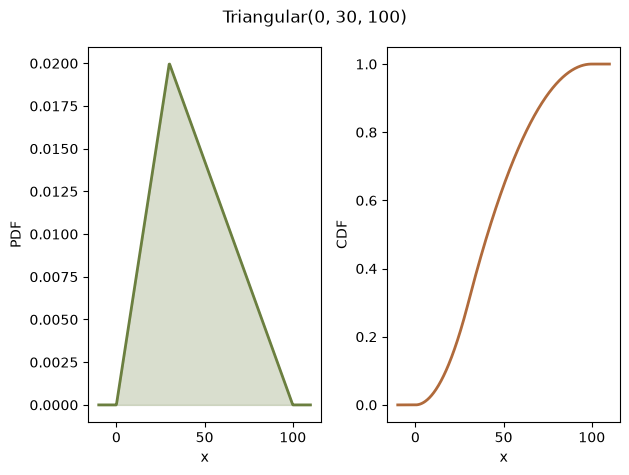

In [9]:
triangular = bf.Distribution("Triangular", [0, 30, 100])
print_statistics(triangular, "Triangular(0, 30, 100)")
plot_distribution(triangular, x_range=(-10, 110), title="Triangular(0, 30, 100)")


PERT(10, 50, 100) statistics:
      Statistic    Value
           Mean  51.6667
  Std Deviation  16.9617
       Variance 287.6984
       Skewness   0.0983
       Kurtosis   2.3462
        Minimum  10.0000
        Maximum 100.0000
 5th Percentile  24.4643
         Median  51.2732
95th Percentile  80.2234


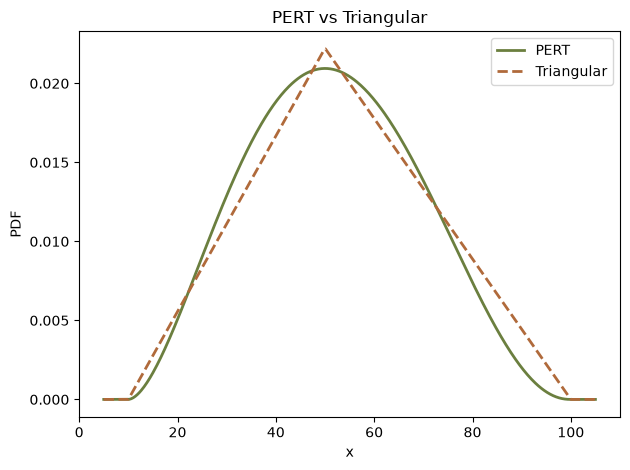

In [10]:
pert = bf.Distribution("Pert", [10, 50, 100])
print_statistics(pert, "PERT(10, 50, 100)")

# Compare PERT vs Triangular with the same min / most likely / max
tri = bf.Distribution("Triangular", [10, 50, 100])
x = np.linspace(5, 105, 500)
plt.figure()
plt.plot(x, pert.pdf(x), color=OLIVE, linewidth=2, label="PERT")
plt.plot(x, tri.pdf(x), color=CLAY, linewidth=2, linestyle="--", label="Triangular")
plt.xlabel("x")
plt.ylabel("PDF")
plt.title("PERT vs Triangular")
plt.legend()
plt.tight_layout()
plt.show()

## Discrete distributions

The library uses `pdf()` for both continuous and discrete families; for discrete
distributions, read `pdf()` as the probability mass function (PMF).

### Poisson

The Poisson distribution models counts of events over a fixed interval when
events occur independently at a constant average rate $\lambda$:

$$
P(X=k) = \frac{\lambda^{k} e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots
$$

Mean and variance are both $\lambda$.

**When to use:** count data, events per time period, rare events.


Poisson(3.5) statistics:
      Statistic  Value
           Mean 3.5000
  Std Deviation 1.8708
       Variance 3.5000
       Skewness 0.5345
       Kurtosis 3.2857
        Minimum 0.0000
        Maximum    inf
 5th Percentile 1.0000
         Median 3.0000
95th Percentile 7.0000


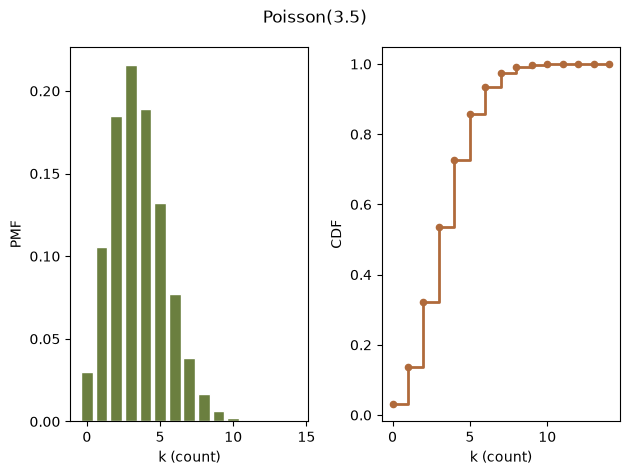

P(X = 3): 0.2158
P(X <= 5): 0.8576


In [11]:
poisson = bf.Distribution("Poisson", [3.5])
print_statistics(poisson, "Poisson(3.5)")

k = np.arange(0, 15)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.bar(k, poisson.pdf(k.astype(float)), color=OLIVE, edgecolor="white")
ax1.set_xlabel("k (count)")
ax1.set_ylabel("PMF")
ax2.step(k, poisson.cdf(k.astype(float)), where="post", color=CLAY, linewidth=2)
ax2.scatter(k, poisson.cdf(k.astype(float)), color=CLAY, s=20, zorder=3)
ax2.set_xlabel("k (count)")
ax2.set_ylabel("CDF")
fig.suptitle("Poisson(3.5)")
plt.tight_layout()
plt.show()

print(f"P(X = 3): {poisson.pdf(3):.4f}")
print(f"P(X <= 5): {poisson.cdf(5):.4f}")

### Binomial

The Binomial distribution models the number of successes in $n$ independent
Bernoulli trials with success probability $p$:

$$
P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n
$$

The constructor order matches the C# class: probability first, then the number of
trials.

**When to use:** fixed number of trials with binary outcomes.


Binomial(p=0.3, n=20) statistics:
      Statistic   Value
           Mean  6.0000
  Std Deviation  2.0494
       Variance  4.2000
       Skewness  0.1952
       Kurtosis  2.9381
        Minimum  0.0000
        Maximum 20.0000
 5th Percentile  3.0000
         Median  6.0000
95th Percentile  9.0000


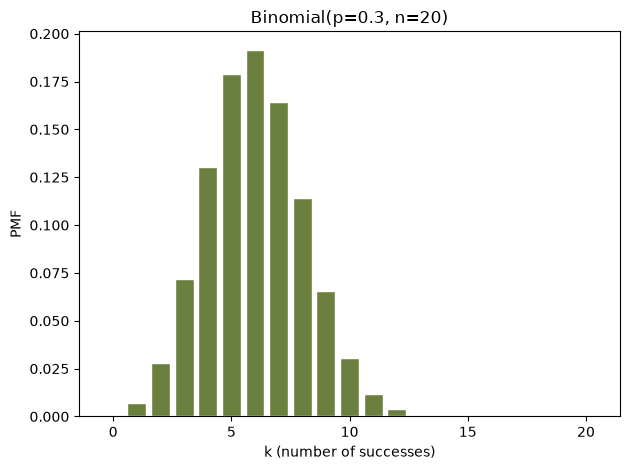

Expected value: 6.00
Most likely value: 6


In [12]:
binomial = bf.Distribution("Binomial", [0.3, 20])
print_statistics(binomial, "Binomial(p=0.3, n=20)")

k = np.arange(0, 21)
plt.figure()
plt.bar(k, binomial.pdf(k.astype(float)), color=OLIVE, edgecolor="white")
plt.xlabel("k (number of successes)")
plt.ylabel("PMF")
plt.title("Binomial(p=0.3, n=20)")
plt.tight_layout()
plt.show()

bm = binomial.moments()
print(f"Expected value: {bm['mean']:.2f}")
print(f"Most likely value: {int(bm['mean'])}")

## Generating and analyzing random samples

Every univariate distribution has a `random()` method (the port of
`GenerateRandomValues`). The upstream notebook draws these samples unseeded; here
they are seeded so the histograms and the table below reproduce exactly, in both
languages. The sample statistics therefore differ from the upstream run's
unseeded table, but match the R version of this page bit for bit.

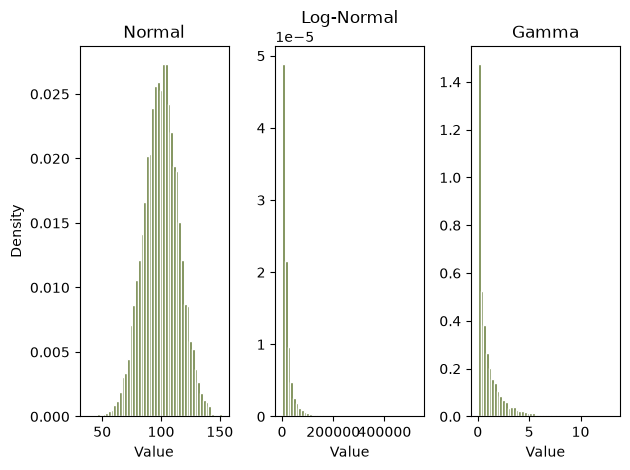


Sample statistics (seed=42):
Distribution  Sample Mean   Sample Std  Sample Skew
      Normal    99.900133    14.994543    -0.044765
  Log-Normal 19028.289596 29289.105202     5.599115
       Gamma     0.987589     1.382078     2.682445


In [13]:
n_samples = 10000

normal_samples = bf.Distribution("Normal", [100, 15]).random(n_samples, seed=42)
lognormal_samples = bf.Distribution("LogNormal", [4, 0.5]).random(n_samples, seed=42)
gamma_samples = bf.Distribution("GammaDistribution", [2, 0.5]).random(n_samples, seed=42)

fig, axes = plt.subplots(1, 3)
for ax, samples, name in zip(
    axes,
    [normal_samples, lognormal_samples, gamma_samples],
    ["Normal", "Log-Normal", "Gamma"],
):
    ax.hist(samples, bins=50, density=True, color=OLIVE, edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("Value")
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()


def sample_skew(x):
    """Adjusted Fisher-Pearson sample skewness (same formula as the R twin)."""
    x = np.asarray(x)
    n = len(x)
    g1 = np.mean((x - x.mean()) ** 3) / np.mean((x - x.mean()) ** 2) ** 1.5
    return g1 * np.sqrt(n * (n - 1)) / (n - 2)


stats_df = pd.DataFrame({
    "Distribution": ["Normal", "Log-Normal", "Gamma"],
    "Sample Mean": [s.mean() for s in [normal_samples, lognormal_samples, gamma_samples]],
    "Sample Std": [s.std(ddof=1) for s in [normal_samples, lognormal_samples, gamma_samples]],
    "Sample Skew": [sample_skew(s) for s in [normal_samples, lognormal_samples, gamma_samples]],
})
print("\nSample statistics (seed=42):")
print(stats_df.to_string(index=False))

### Latin hypercube sampling

Latin hypercube sampling (LHS) is a stratified sampling technique. Each
dimension's $[0, 1)$ range is divided into $n$ equal strata and exactly one
sample lands in each stratum:

$$
x_{ij} = \frac{\pi_j(i) + U_{ij}}{n}, \quad i = 0, \ldots, n-1
$$

where $\pi_j$ is an independent random permutation for each dimension and
$U_{ij} \sim \text{Uniform}(0, 1)$. The `median=True` variant replaces $U_{ij}$
with 0.5, placing each point at its stratum center. Projected onto any single
axis, the samples fall exactly one per stratum, which removes the clustering and
gaps of simple random sampling. LHS often reaches the accuracy of plain Monte
Carlo with 5 to 10 times fewer samples.

**When to use:** Monte Carlo with a limited budget, sensitivity analysis,
calibration of expensive models, risk assessment.

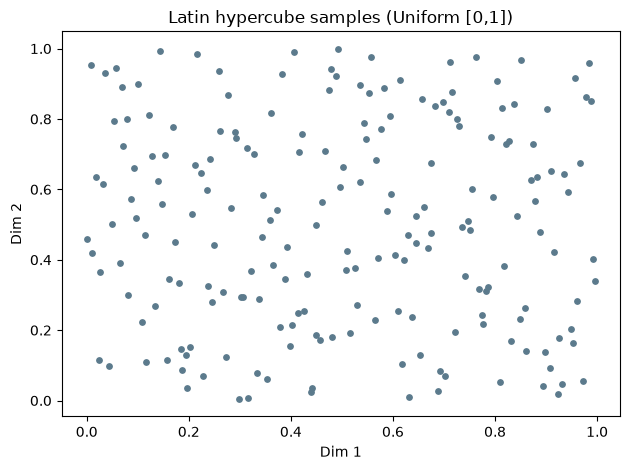

One sample per stratum in every dimension: True


In [14]:
lhs = bf.latin_hypercube(200, 2, seed=12345)

plt.figure()
plt.scatter(lhs[:, 0], lhs[:, 1], s=15, color=SLATE)
plt.title("Latin hypercube samples (Uniform [0,1])")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()

# The defining property: sorted samples in each dimension fall one per stratum.
n = lhs.shape[0]
stratified = all(
    (i / n <= s < (i + 1) / n)
    for j in range(lhs.shape[1])
    for i, s in enumerate(np.sort(lhs[:, j]))
)
print(f"One sample per stratum in every dimension: {stratified}")

## Comparing multiple distributions

More than one distribution may fit a dataset well, so it pays to consider several
candidates. Here we simulate 50 years of annual peak flows from a Log-Normal
distribution (seeded, so the data reproduce exactly) and fit three candidates by
maximum likelihood. Every family fits through `bf.Distribution.fit`; GEV also has a dedicated
`bf.gev_fit` helper whose bespoke path carries quantile standard errors.
Distribution fitting is covered properly in the next example.

Log-Normal fit: Distribution(LogNormal(µ = 8.01748, σ = 0.383659))
Weibull fit: params = [1.62478206e+08 1.02370000e+00]
GEV fit: {'location': 80617292.83426607, 'scale': 62469721.14348653, 'shape': -0.3892412965035586}


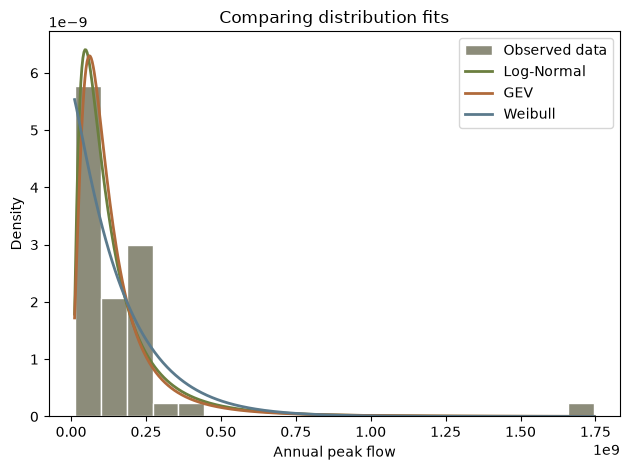

In [15]:
# Simulate flood frequency data (seeded; upstream uses the same seed)
observed_data = bf.Distribution("LogNormal", [8, 0.6]).random(50, seed=123)

lognormal_fit = bf.Distribution.fit("LogNormal", observed_data, method="mle")
weibull_fit = bf.Distribution.fit("Weibull", observed_data, method="mle")
gev_fit = bf.Distribution.fit("GeneralizedExtremeValue", observed_data, method="mle")
g = dict(zip(("location", "scale", "shape"), gev_fit.params))

print(f"Log-Normal fit: {lognormal_fit}")
print(f"Weibull fit: params = {np.round(weibull_fit.params, 4)}")
print(f"GEV fit: {g}")

plt.figure()
plt.hist(observed_data, bins=20, density=True, color=GRAY, edgecolor="white",
         label="Observed data")
x = np.linspace(observed_data.min(), observed_data.max(), 500)
plt.plot(x, lognormal_fit.pdf(x), color=OLIVE, linewidth=2, label="Log-Normal")
plt.plot(x, gev_fit.pdf(x), color=CLAY, linewidth=2, label="GEV")
plt.plot(x, weibull_fit.pdf(x), color=SLATE, linewidth=2, label="Weibull")
plt.xlabel("Annual peak flow")
plt.ylabel("Density")
plt.title("Comparing distribution fits")
plt.legend()
plt.tight_layout()
plt.show()

## Distribution selection guide

| Distribution | Type | Typical use case | Parameters |
|---|---|---|---|
| Normal | Continuous | Symmetric data, measurements | $\mu$, $\sigma$ |
| Log-Normal | Continuous | Right-skewed positive data | $\mu$, $\sigma$ |
| Uniform | Continuous | Equal probability over range | min, max |
| Triangular | Continuous | Bounded with mode | min, mode, max |
| PERT | Continuous | Project estimates | min, mode, max |
| Gamma | Continuous | Positive data, waiting times | $\theta$, $\kappa$ |
| Weibull | Continuous | Reliability, failure time | $\lambda$, $\kappa$ |
| Exponential | Continuous | Time between events | $\lambda$ |
| Gumbel | Continuous | Extreme maxima | $\xi$, $\alpha$ |
| GEV | Continuous | General extreme values | $\xi$, $\alpha$, $\kappa$ |
| Beta | Continuous | Proportions on [0,1] | $\alpha$, $\beta$ |
| Poisson | Discrete | Count data, rare events | $\lambda$ |
| Binomial | Discrete | Binary outcomes, trials | $n$, $p$ |
| Bernoulli | Discrete | Single trial success/failure | $p$ |

## Summary

You have now explored:

- Creating distributions with different parameters.
- Computing PDF, CDF, and quantile values.
- Generating random samples, including Latin hypercube designs.
- Visualizing distributions.
- Understanding when to use each distribution.

## Exercise

Try creating and plotting these distributions on your own (use
`d.parameter_names` to check the constructor order):

1. `bf.Distribution("Beta", [2, 5])` - useful for probabilities and proportions.
2. `bf.Distribution("StudentT", ...)` with 3 degrees of freedom - a heavy-tailed
   alternative to the Normal.
3. `bf.Distribution("ChiSquared", [5])` - goodness-of-fit testing.

## Reproduction check

Values printed by the upstream notebook (run against the real C# library),
compared with this port. Everything here is deterministic, so the match is exact;
most upstream tables print 4 decimal places (or 7 significant figures for the
Log-Normal), so those rows are compared at the precision upstream shows. The
seeded draws, the Latin hypercube design, and the fitted parameters are
additionally asserted bit-identical to the R version of this page.

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| `Normal(100,15).InverseCDF(0.05)` | 75.32719559572791 | `normal.quantile(0.05)` | exact |
| `Normal(100,15).InverseCDF(0.95)` | 124.67280440427207 | `normal.quantile(0.95)` | exact |
| `LogNormal(4,0.5).Mean` | 1.940096e+04 | `moments()["mean"]` | exact (7 sig figs shown) |
| `LogNormal(4,0.5).Kurtosis` | 346.8718 | `moments()["kurtosis"]` | exact (4 dp shown) |
| `LogNormal(4,0.5).InverseCDF(0.95)` | 6.643957e+04 | `.quantile(0.95)` | exact (7 sig figs shown) |
| GEV(100,15,-0.5) mean / min | 123.1736 / 70.0 | `moments()` | exact (4 dp shown) |
| GEV(100,15,0) mean / sd | 108.6582 / 19.2382 | `moments()` | exact (4 dp shown) |
| GEV(100,15,0.5) mean / max | 103.4132 / 130.0 | `moments()` | exact (4 dp shown) |
| Gamma(2,0.5) mean / kurtosis | 1.0 / 15.0 | `moments()` | exact |
| Gamma(2,0.5).InverseCDF(0.95) | 3.8415 | `.quantile(0.95)` | exact (4 dp shown) |
| Weibull(100,2.5) mean | 88.7264 | `moments()["mean"]` | exact (4 dp shown) |
| Uniform(0,100) sd / kurtosis | 28.8675 / 1.8 | `moments()` | exact |
| Triangular(0,30,100) mean / median | 43.3333 / 40.8392 | `moments()`, `.quantile(0.5)` | exact (4 dp shown) |
| PERT(10,50,100) mean / median | 51.6667 / 51.2732 | `moments()`, `.quantile(0.5)` | exact (4 dp shown) |
| Poisson(3.5) P(X=3) / P(X<=5) | 0.2158 / 0.8576 | `.pdf(3)`, `.cdf(5)` | exact (4 dp shown) |
| Binomial(0.3,20) mean / 95th pct | 6.0 / 9.0 | `moments()`, `.quantile(0.95)` | exact |
| First draw, `LogNormal(8,0.6)` seed 123 | (not printed upstream) | bit-identical to R twin | exact |
| LHS(200, 2, seed 12345) first point | (not printed upstream) | bit-identical to R twin | exact |

The cell below fails the notebook if any value drifts.

In [16]:
# Upstream reference values: 01_distributions.ipynb, cells 4, 8, 10, 12, 14,
# 16, 18, 20, 22, 24 outputs. Upstream tables print DataFrame.round(4), so
# 4-decimal literals are compared at that precision; the underlying math is
# deterministic.
def shown(x, literal, tol=5e-5):
    return abs(x - literal) < tol


# Normal(100, 15) -- full-precision f-string prints upstream
nm = bf.Distribution("Normal", [100, 15])
assert nm.quantile(0.05) == 75.32719559572791
assert nm.quantile(0.5) == 100.0
assert nm.quantile(0.95) == 124.67280440427207

# LogNormal(4, 0.5) -- shown to 7 significant figures upstream
ln_m = bf.Distribution("LogNormal", [4, 0.5]).moments()
assert abs(ln_m["mean"] / 1.940096e4 - 1) < 1e-6
assert abs(ln_m["sd"] / 3.225447e4 - 1) < 1e-6
assert shown(ln_m["skewness"], 9.5827)
assert shown(ln_m["kurtosis"], 346.8718)
ln_d = bf.Distribution("LogNormal", [4, 0.5])
assert abs(ln_d.quantile(0.05) / 1.505127e3 - 1) < 1e-6
assert abs(ln_d.quantile(0.95) / 6.643957e4 - 1) < 1e-6

# GEV shapes
fm, gm_, wm = (gev_frechet.moments(), gev_gumbel.moments(), gev_weibull.moments())
assert shown(fm["mean"], 123.1736) and fm["minimum"] == 70.0
assert shown(gev_frechet.quantile(0.95), 202.4619)
assert shown(gm_["mean"], 108.6582) and shown(gm_["sd"], 19.2382)
assert shown(gm_["skewness"], 1.1396) and gm_["kurtosis"] == 5.4
assert shown(gev_gumbel.quantile(0.5), 105.4977)
assert shown(wm["mean"], 103.4132) and wm["maximum"] == 130.0
assert shown(gev_weibull.quantile(0.95), 123.2056)

# Gamma(2, 0.5)
gam_m = gamma.moments()
assert gam_m["mean"] == 1.0 and gam_m["kurtosis"] == 15.0
assert shown(gam_m["sd"], 1.4142) and shown(gam_m["skewness"], 2.8284)
assert shown(gamma.quantile(0.5), 0.4549) and shown(gamma.quantile(0.95), 3.8415)

# Weibull(100, 2.5)
wb_m = weibull.moments()
assert shown(wb_m["mean"], 88.7264) and shown(wb_m["sd"], 37.9667)
assert shown(weibull.quantile(0.95), 155.0962)

# Uniform, Triangular, PERT
un_m = uniform.moments()
assert un_m["mean"] == 50.0 and un_m["kurtosis"] == 1.8 and shown(un_m["sd"], 28.8675)
tr_m = triangular.moments()
assert shown(tr_m["mean"], 43.3333) and shown(tr_m["skewness"], 0.3561)
assert shown(triangular.quantile(0.5), 40.8392) and shown(triangular.quantile(0.95), 81.2917)
pt_m = pert.moments()
assert shown(pt_m["mean"], 51.6667) and shown(pt_m["sd"], 16.9617)
assert shown(pert.quantile(0.5), 51.2732) and shown(pert.quantile(0.95), 80.2234)

# Poisson(3.5) and Binomial(0.3, 20)
po_m = poisson.moments()
assert po_m["mean"] == 3.5 and shown(po_m["sd"], 1.8708)
assert shown(poisson.pdf(3), 0.2158, tol=5e-5) and shown(poisson.cdf(5), 0.8576, tol=5e-5)
assert poisson.quantile(0.95) == 7.0
bi_m = binomial.moments()
assert bi_m["mean"] == 6.0 and shown(bi_m["sd"], 2.0494)
assert binomial.quantile(0.05) == 3.0 and binomial.quantile(0.95) == 9.0

# Seeded values, bit-identical across Python, R, and the C# library
assert normal_samples[0] == 95.20221411105254
assert observed_data[0] == 203499515.64666739
assert lhs[0, 0] == 0.12249509909539484
assert lhs[0, 1] == 0.81019698383868677
assert stratified
# Log-Normal MLE is deterministic (closed-form in log space); the tolerance
# only guards platform libm differences.
assert abs(lognormal_fit.params[0] / 8.0174794125819 - 1) < 1e-12
assert abs(lognormal_fit.params[1] / 0.383659272555292 - 1) < 1e-12

print("All reproduction checks passed.")

All reproduction checks passed.
